# Ejercicio 6 — Benchmark: Parquet frente a tablas DuckDB

Trabajo individual. Se comparan cinco consultas representativas con tres cantidades de datos: enero de 2024, enero–junio de 2024 y todo el conjunto descargado de 2024 y 2026.

Este notebook revisa los tiempos **realmente medidos** por `scripts/benchmark.py`. No genera tiempos simulados. Para reproducir las mediciones ejecute el comando del README o active RUN_BENCHMARK en la siguiente celda. Por defecto carga los resultados existentes y no repite el benchmark al abrirlo.

Las tablas se materializan en archivos locales `.duckdb`, excluidos de Git. El notebook contiene condiciones, consultas SQL, tablas de tiempos, gráficos, equivalencia e interpretación.

In [1]:
from pathlib import Path
import os
import sys
import json
import subprocess
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "scripts" / "benchmark.py").exists())
os.chdir(ROOT)
RESULTS = ROOT / "docs" / "resultados_ejercicio_6"
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 60)
RUN_BENCHMARK = False
if RUN_BENCHMARK:
    subprocess.run([sys.executable, "scripts/benchmark.py", "--repetitions", "5",
                    "--warmups", "1", "--threads", "4", "--memory-limit", "2GB",
                    "--seed", "42"], check=True)
if not (RESULTS / "tiempos.csv").exists():
    raise FileNotFoundError("Primero ejecute scripts/benchmark.py o active RUN_BENCHMARK.")
environment = json.loads((RESULTS / "entorno.json").read_text())
print(json.dumps(environment, indent=2, ensure_ascii=False))

{
  "fecha_utc": "2026-10-07T18:37:11.554637+00:00",
  "duckdb": "1.5.5",
  "python": "3.11.14",
  "sistema": "Linux-6.5.11-linuxkit-aarch64-with-glibc2.41",
  "arquitectura": "aarch64",
  "cpus_visibles": 8,
  "cgroup_memory_max": "max",
  "cgroup_cpu_max": "max 100000",
  "threads": 4,
  "memory_limit": "2GB",
  "repeticiones": 5,
  "calentamientos": 1,
  "semilla": 42,
  "conexion_mediciones": "read_only, una por nivel y ambas estrategias",
  "caches": "un calentamiento mínimo; no se vacían cachés del SO; materialización previa lee los Parquet",
  "temporizador": "perf_counter; execute y fetchall; excluye comparación, CSV, EXPLAIN y materialización",
  "tolerancia": {
    "enteros_y_categorias": "exacta",
    "flotantes_rtol": 1e-09,
    "flotantes_atol": 1e-08
  },
  "orden": "consultas barajadas por ronda; estrategias alternadas por par; secuencial",
  "otros_servicios": "Jupyter, Metabase y otros contenedores pueden permanecer activos; no se aísla toda carga del host",
  "niveles

## 6.1 y 6.2 — Fuentes y materialización

Para cada nivel, las vistas temporales de Parquet usan listas explícitas de archivos de `docs/preparacion_benchmark.json`. Se conservan el esquema lógico, los valores originales, el archivo de procedencia y el mes de archivo.

La tabla se crea a partir de la misma vista y se persiste con CHECKPOINT. Después se cierra la conexión de escritura y se reabre la base en read_only para medir ambas estrategias desde una misma conexión por nivel.

La materialización incluye campos derivados de origen/mes; la consulta externa los calcula en la vista. El costo de ese trabajo previo está separado de los tiempos de consultas. No se crean índices ni una ordenación deliberada. Solo la tabla `viajes_duckdb` persiste; las vistas externas son temporales.

In [2]:
print((ROOT / "sql" / "benchmark" / "00_materializar.sql").read_text())
materialization = pd.read_csv(RESULTS / "materializacion.csv")
display(materialization[["nivel", "registros", "cantidad_archivos", "bytes_parquet", "bytes_duckdb",
                         "preparacion_s", "creacion_tabla_s", "checkpoint_s", "materializacion_s"]])

-- La fuente externa ya armoniza nombres y columnas, sin limpiar ni filtrar filas.
-- Se conserva el mismo esquema lógico, procedencia y todos los registros.
CREATE TABLE viajes_duckdb AS SELECT * FROM viajes_parquet;
CHECKPOINT;



,nivel,registros,cantidad_archivos,bytes_parquet,bytes_duckdb,preparacion_s,creacion_tabla_s,checkpoint_s,materializacion_s
0,pequeno,3021175,2,51323925,87568384,0.035559,5.688015,0.110178,5.833753
1,mediano,20671900,12,350080949,589836288,0.038979,10.390375,0.373011,10.802365
2,completo,71870407,40,1228648745,2033201152,0.034309,38.692490,0.475570,39.202369


## 6.3 y 6.4 — Consultas representativas

Las plantillas siguientes se ejecutan dos veces: sustituyendo únicamente `{{fuente}}` por `viajes_parquet` o por `viajes_duckdb`. Las condiciones y agregaciones son las mismas. Los resultados se ordenan para verificar su equivalencia.

Los conteos y categorías se comparan exactamente; las medias admiten pequeñas diferencias de acumulación flotante (rtol=1e-9, atol=1e-8). No se incluyen percentiles aproximados porque pueden cambiar con el orden de procesamiento.

### 01_conteo: Conteo por taxi

**Objetivo:** Inventario de registros; algunos conteos pueden aprovechar metadatos.

**Origen:** Ejercicio 3: inventario.

**Fuente:** los archivos exactos de cada nivel, o su tabla materializada equivalente.

In [3]:
print((ROOT / "sql" / "benchmark" / '01_conteo.sql').read_text())

-- Inventario representativo: permite observar optimizaciones de conteo.
SELECT tipo_taxi, count(*) AS viajes
FROM {{fuente}}
GROUP BY tipo_taxi ORDER BY tipo_taxi;



### 02_demanda_mensual: Demanda mensual

**Objetivo:** Agrupación temporal con el mismo criterio de fechas válidas del EDA.

**Origen:** Ejercicio 4: demanda mensual.

**Fuente:** los archivos exactos de cada nivel, o su tabla materializada equivalente.

In [4]:
print((ROOT / "sql" / "benchmark" / '02_demanda_mensual.sql').read_text())

-- Misma población temporal del EDA: recogida coherente con el mes del archivo.
SELECT tipo_taxi, mes_archivo, count(*) AS viajes
FROM {{fuente}}
WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
GROUP BY tipo_taxi, mes_archivo ORDER BY tipo_taxi, mes_archivo;



### 03_formas_pago: Formas de pago

**Objetivo:** Agrupación categórica y conteo condicional de importes negativos.

**Origen:** Ejercicio 4: modalidades de pago e importes negativos.

**Fuente:** los archivos exactos de cada nivel, o su tabla materializada equivalente.

In [5]:
print((ROOT / "sql" / "benchmark" / '03_formas_pago.sql').read_text())

-- Conteos y totales negativos por categoría; conserva el pago nulo.
SELECT tipo_taxi, payment_type, count(*) AS viajes,
       count_if(total_amount < 0) AS totales_negativos
FROM {{fuente}}
WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
GROUP BY tipo_taxi, payment_type ORDER BY tipo_taxi, payment_type;



### 04_caracteristicas: Características

**Objetivo:** Filtros de calidad y medias de distancia, duración y total; evita percentiles aproximados para verificar equivalencia.

**Origen:** Ejercicio 4: perfil de viajes y sensibilidad.

**Fuente:** los archivos exactos de cada nivel, o su tabla materializada equivalente.

In [6]:
print((ROOT / "sql" / "benchmark" / '04_caracteristicas.sql').read_text())

-- Medias del subconjunto declarado en el EDA; no se usan percentiles aproximados.
SELECT tipo_taxi, count(*) AS viajes,
       avg(trip_distance) AS distancia_media_millas,
       avg(date_diff('second', recogida, llegada) / 60.0) AS duracion_media_minutos,
       avg(total_amount) AS total_medio_usd
FROM {{fuente}}
WHERE recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
  AND trip_distance > 0 AND trip_distance <= 100
  AND date_diff('second', recogida, llegada) > 0
  AND date_diff('second', recogida, llegada) <= 86400
  AND total_amount > 0 AND fare_amount >= 0
GROUP BY tipo_taxi ORDER BY tipo_taxi;



### 05_filtro_fecha_zona: Fecha y zona

**Objetivo:** Filtro selectivo en una semana fija de enero de 2024, con agrupación por zona y tipo.

**Origen:** Ejercicio 4: análisis temporal, distancia y pagos.

**Fuente:** los archivos exactos de cada nivel, o su tabla materializada equivalente.

In [7]:
print((ROOT / "sql" / "benchmark" / '05_filtro_fecha_zona.sql').read_text())

-- Consulta selectiva: intervalo fijo presente en los tres tamaños.
SELECT tipo_taxi, zona_origen, count(*) AS viajes, avg(total_amount) AS total_medio_usd
FROM {{fuente}}
WHERE recogida >= TIMESTAMP '2024-01-10 00:00:00'
  AND recogida < TIMESTAMP '2024-01-17 00:00:00'
  AND recogida >= mes_archivo AND recogida < mes_archivo + INTERVAL 1 MONTH
  AND payment_type = 1 AND trip_distance > 0 AND trip_distance <= 100
  AND total_amount > 0
GROUP BY tipo_taxi, zona_origen ORDER BY tipo_taxi, zona_origen;



## 6.5–6.7 — Mediciones, repeticiones y escala

Se realiza un calentamiento por consulta y estrategia, excluido del resumen. Después hay cinco repeticiones medidas. Las consultas se barajan con semilla fija y se alterna la estrategia que va primero en cada par. No se ejecutan benchmarks en paralelo.

El cronómetro incluye `execute` y `fetchall` de los resultados pequeños; excluye comparación, exportación, EXPLAIN y materialización. Son ejecuciones recurrentes, **no caché fría**: no se vacía la caché del sistema operativo, y la construcción previa ya leyó los Parquet. El calentamiento no asegura que todo el conjunto esté en memoria.

Se mantienen los mismos hilos y memory_limit en ambas estrategias. Docker comparte recursos y volúmenes con macOS; los resultados describen este entorno, no todas las máquinas.

In [8]:
timings = pd.read_csv(RESULTS / "tiempos.csv")
summary = pd.read_csv(RESULTS / "resumen.csv")
comparison = pd.read_csv(RESULTS / "comparacion.csv")
display(summary)
display(comparison)
print("Ejecuciones medidas:", len(timings))
print("Ejecuciones de calentamiento:", len(pd.read_csv(RESULTS / "calentamientos.csv")))

,nivel,registros,consulta,estrategia,repeticiones,mediana_s,media_s,minimo_s,maximo_s,desviacion_s
0,pequeno,3021175,04_caracteristicas,parquet,5,0.097158,0.101696,0.087582,0.131881,0.017999
1,pequeno,3021175,04_caracteristicas,duckdb,5,0.046928,0.046363,0.037159,0.056884,0.008530
2,pequeno,3021175,03_formas_pago,duckdb,5,0.027734,0.030398,0.022757,0.046078,0.009422
3,pequeno,3021175,03_formas_pago,parquet,5,0.055906,0.057957,0.051569,0.070226,0.007142
4,pequeno,3021175,01_conteo,parquet,5,0.008506,0.008440,0.007637,0.009410,0.000651
5,pequeno,3021175,01_conteo,duckdb,5,0.003489,0.003502,0.003321,0.003699,0.000184
6,pequeno,3021175,05_filtro_fecha_zona,duckdb,5,0.008734,0.009672,0.008184,0.014076,0.002476
7,pequeno,3021175,05_filtro_fecha_zona,parquet,5,0.045403,0.055186,0.044461,0.093982,0.021704
8,pequeno,3021175,02_demanda_mensual,parquet,5,0.025245,0.032411,0.023247,0.062452,0.016863
9,pequeno,3021175,02_demanda_mensual,duckdb,5,0.019594,0.019688,0.016090,0.023607,0.003448


,nivel,registros,consulta,duckdb_mediana_s,parquet_mediana_s,razon_parquet_duckdb,menor_mediana
0,completo,71870407,01_conteo,0.072141,0.119634,1.658342,duckdb
1,completo,71870407,02_demanda_mensual,0.286995,0.495517,1.726568,duckdb
2,completo,71870407,03_formas_pago,0.459844,1.113174,2.420766,duckdb
3,completo,71870407,04_caracteristicas,1.157525,2.418146,2.089065,duckdb
4,completo,71870407,05_filtro_fecha_zona,0.028241,0.432831,15.326123,duckdb
5,mediano,20671900,01_conteo,0.023123,0.034079,1.473835,duckdb
6,mediano,20671900,02_demanda_mensual,0.071665,0.115961,1.618105,duckdb
7,mediano,20671900,03_formas_pago,0.107938,0.233572,2.163950,duckdb
8,mediano,20671900,04_caracteristicas,0.287754,0.509564,1.770832,duckdb
9,mediano,20671900,05_filtro_fecha_zona,0.015690,0.156212,9.955889,duckdb


Ejecuciones medidas: 150
Ejecuciones de calentamiento: 30


In [9]:
equivalence = pd.read_csv(RESULTS / "equivalencia.csv")
assert equivalence.resultados_equivalentes.all()
assert timings.equivalencia_ok.all()
assert (timings.groupby(["nivel", "consulta", "estrategia"]).size() == environment["repeticiones"]).all()
display(equivalence)
print("Resultados y esquemas coinciden en todos los casos y repeticiones.")

,nivel,consulta,filas_resultado,esquema_igual,resultados_equivalentes,verificaciones_medidas
0,pequeno,04_caracteristicas,2,True,True,10
1,pequeno,02_demanda_mensual,2,True,True,10
2,pequeno,03_formas_pago,11,True,True,10
3,pequeno,05_filtro_fecha_zona,332,True,True,10
4,pequeno,01_conteo,2,True,True,10
5,mediano,02_demanda_mensual,12,True,True,10
6,mediano,04_caracteristicas,2,True,True,10
7,mediano,01_conteo,2,True,True,10
8,mediano,03_formas_pago,12,True,True,10
9,mediano,05_filtro_fecha_zona,332,True,True,10


Resultados y esquemas coinciden en todos los casos y repeticiones.


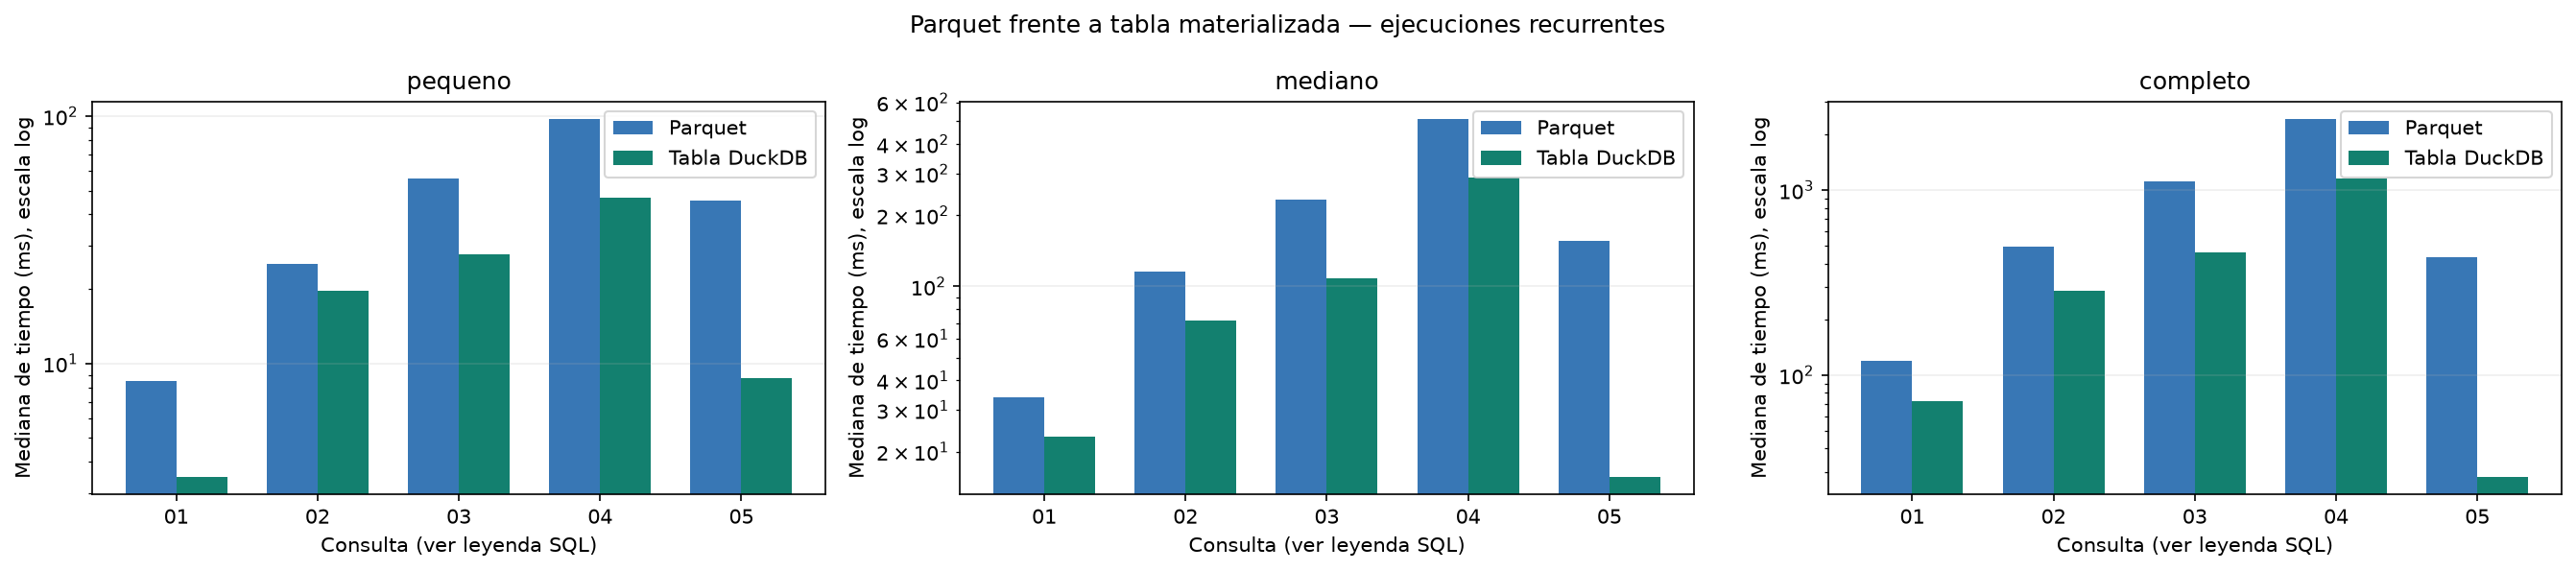

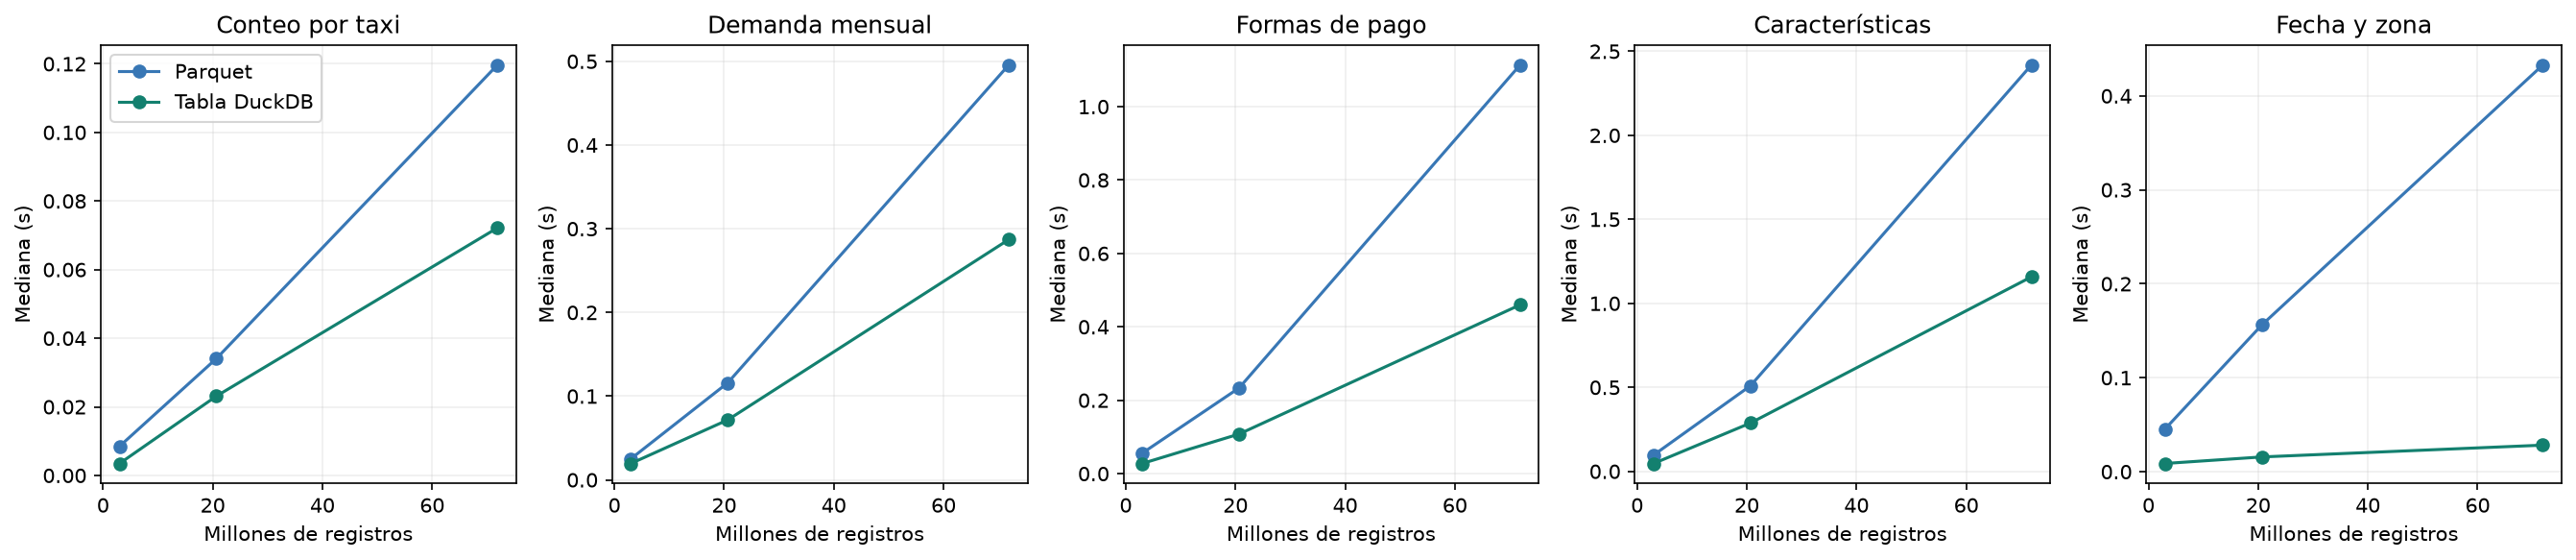

In [10]:
display(Image(filename=str(ROOT / "docs" / "figuras_ejercicio_6" / "tiempos_por_volumen.png")))
display(Image(filename=str(ROOT / "docs" / "figuras_ejercicio_6" / "escalabilidad.png")))

## 6.8 — Documentación y planes

Los SQL están en `sql/benchmark/`. Los resultados por estrategia y tamaño se guardan en `docs/resultados_ejercicio_6/resultados_consultas/`, y EXPLAIN en `docs/resultados_ejercicio_6/planes/`. Los planes se obtienen fuera del cronómetro.

La razón de medianas es tiempo Parquet / tiempo DuckDB: mayor que 1 favorece la tabla; menor que 1 favorece Parquet. Una menor mediana observada no prueba significancia estadística. Deben revisarse tiempos absolutos, variación y costo de construir la tabla.

## 6.9 — Interpretación respaldada por las mediciones

In [11]:
report = (ROOT / "docs" / "ejercicio_6_benchmark.md").read_text()
interpretation = report.split("## 6.9: interpretación de resultados", 1)[1].split("## 6.10:", 1)[0]
display(Markdown(interpretation))



**pequeno:** la tabla tiene menor mediana en 5/5 consultas. La razón mayor es 5.20× en 05_filtro_fecha_zona; la menor, 1.29× en 02_demanda_mensual. Estos extremos se interpretan junto con los tiempos absolutos y la dispersión, especialmente en consultas de pocos milisegundos.

Una ronda que ejecuta una vez las cinco consultas tendría, sumando medianas observadas, un ahorro aproximado de 0.1257 s con la tabla. El costo de construcción de 5.83 s se compensaría alrededor de 47 rondas similares. Es una estimación bajo carga estable, no un umbral garantizado ni una medición de rondas completas; excluye mantenimiento, almacenamiento y cambios de datos.

**mediano:** la tabla tiene menor mediana en 5/5 consultas. La razón mayor es 9.96× en 05_filtro_fecha_zona; la menor, 1.47× en 01_conteo. Estos extremos se interpretan junto con los tiempos absolutos y la dispersión, especialmente en consultas de pocos milisegundos.

Una ronda que ejecuta una vez las cinco consultas tendría, sumando medianas observadas, un ahorro aproximado de 0.5432 s con la tabla. El costo de construcción de 10.80 s se compensaría alrededor de 20 rondas similares. Es una estimación bajo carga estable, no un umbral garantizado ni una medición de rondas completas; excluye mantenimiento, almacenamiento y cambios de datos.

**completo:** la tabla tiene menor mediana en 5/5 consultas. La razón mayor es 15.33× en 05_filtro_fecha_zona; la menor, 1.66× en 01_conteo. Estos extremos se interpretan junto con los tiempos absolutos y la dispersión, especialmente en consultas de pocos milisegundos.

Una ronda que ejecuta una vez las cinco consultas tendría, sumando medianas observadas, un ahorro aproximado de 2.5746 s con la tabla. El costo de construcción de 39.20 s se compensaría alrededor de 16 rondas similares. Es una estimación bajo carga estable, no un umbral garantizado ni una medición de rondas completas; excluye mantenimiento, almacenamiento y cambios de datos.

El crecimiento del conjunto se observa por consulta, no mediante una única tasa global. Los conteos, agregaciones con filtros y selección por fecha tienen trabajos distintos. Las diferencias pueden estar relacionadas con estadísticas, formato y compresión, descarte de grupos de filas, costo de abrir varios archivos, cachés y los campos derivados precomputados. Estas son explicaciones posibles apoyadas por capacidades de DuckDB; no se aísla causalmente cada factor. Los EXPLAIN guardados permiten revisar los operadores concretos sin añadir su ejecución al tiempo medido.



## 6.10 — Elección de estrategia

**Parquet directo:** consultas ocasionales, exploración, archivos nuevos que se incorporan continuamente y necesidad de evitar una copia adicional. La lectura puede aprovechar columnas seleccionadas y filtros, según consulta y organización.

**Tabla DuckDB:** trabajo repetido sobre una instantánea, integración con herramientas analíticas y casos donde el ahorro observado compensa materialización, espacio y mantenimiento.

La base completa queda en `data/processed/benchmark/completo.duckdb`, con la tabla `viajes_duckdb`. Su uso desde otra herramienta debe ser de solo lectura mientras otros procesos trabajan con ella. Los cambios en datos requieren actualizar o reconstruir esa instantánea.

Las estimaciones de compensación del costo suman medianas de una ronda con cinco consultas; no son tiempos de rondas medidos ni umbrales garantizados. Los tamaños de este experimento varían también en archivos, meses y esquemas, no solo registros.

Referencias: [DuckDB: Parquet](https://duckdb.org/docs/current/data/parquet/overview) y [ajuste de cargas](https://duckdb.org/docs/current/guides/performance/how_to_tune_workloads).